# DishaNifty — XGBoost + RF vs XGBoost Comparison (Task 9)
Owner: Sujal

Same structure as `03_random_forest.ipynb`: reads results already saved
by `src/models/xgb_model.py`, no retraining here. Second half of this
notebook does the head-to-head comparison against Random Forest, which
is the deliverable the roadmap asks for at this phase — this is also
the core evidence for the project's research question (does complexity
help?).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sys.path.append(str(Path.cwd().parent / "src"))
pd.set_option("display.max_colwidth", None)

## Fold-by-fold results

In [2]:
results = pd.read_csv("../results/xgb_fold_results.csv")
results

,fold,best_params,accuracy,macro_f1,precision_down,recall_down,precision_neutral,recall_neutral,precision_up,recall_up
0,1,"{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.9}",0.388000,0.351263,0.345794,0.451220,0.209302,0.204545,0.510000,0.411290
1,2,"{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}",0.411290,0.285180,0.280000,0.088608,0.400000,0.096774,0.427885,0.831776
2,3,"{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.9}",0.375000,0.355330,0.408163,0.425532,0.232143,0.260000,0.425532,0.384615
3,4,"{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}",0.359184,0.323553,0.343558,0.756757,0.413793,0.151899,0.377358,0.217391


In [3]:
print(f"Mean Accuracy: {results['accuracy'].mean():.4f}")
print(f"Mean Macro F1:  {results['macro_f1'].mean():.4f}")

Mean Accuracy: 0.3834
Mean Macro F1:  0.3288


## Per-class precision / recall per fold

In [4]:
results[['fold', 'precision_down', 'recall_down',
          'precision_neutral', 'recall_neutral',
          'precision_up', 'recall_up']]

,fold,precision_down,recall_down,precision_neutral,recall_neutral,precision_up,recall_up
0,1,0.345794,0.451220,0.209302,0.204545,0.510000,0.411290
1,2,0.280000,0.088608,0.400000,0.096774,0.427885,0.831776
2,3,0.408163,0.425532,0.232143,0.260000,0.425532,0.384615
3,4,0.343558,0.756757,0.413793,0.151899,0.377358,0.217391


## Confusion matrices per fold
Rows = actual, columns = predicted. Class order: 0=DOWN, 1=NEUTRAL, 2=UP.

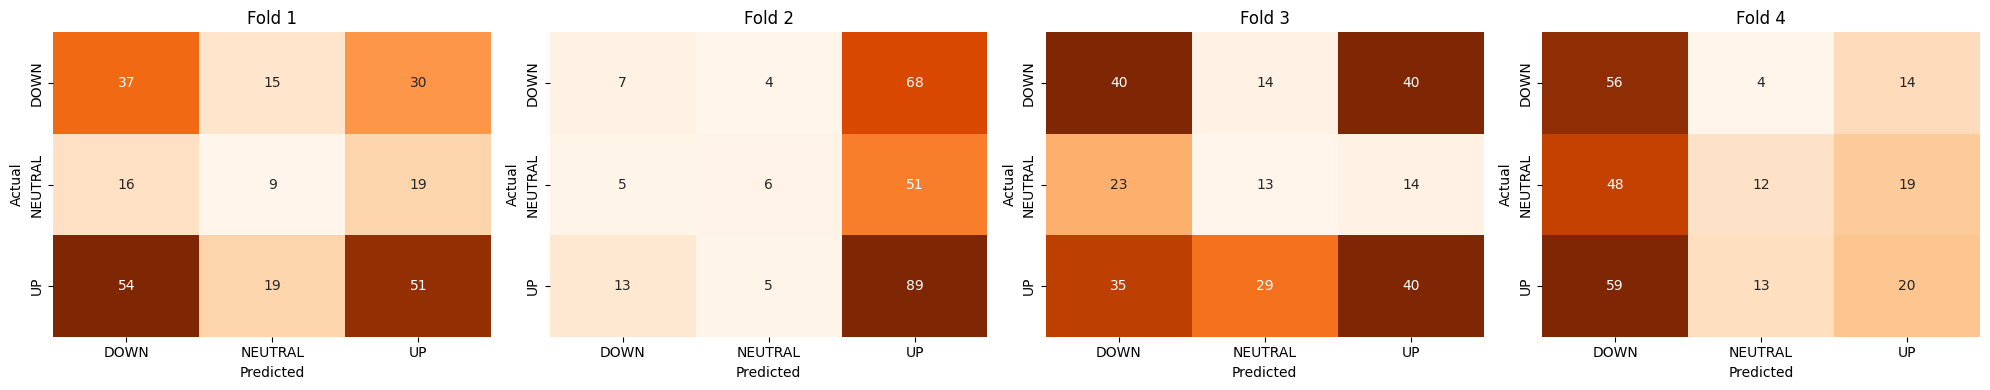

In [5]:
preds = pd.read_csv("../results/xgb_predictions.csv")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
labels = ['DOWN', 'NEUTRAL', 'UP']
for i, fold in enumerate(sorted(preds['fold'].unique())):
    fold_preds = preds[preds['fold'] == fold]
    cm = confusion_matrix(fold_preds['Actual'], fold_preds['Predicted'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=labels, yticklabels=labels, cbar=False)
    axes[i].set_title(f"Fold {fold}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

---
## Head-to-head: Random Forest vs XGBoost
Both models were tuned and evaluated on the exact same 4 walk-forward
folds, so this comparison is apples-to-apples.

In [6]:
rf_results = pd.read_csv("../results/rf_fold_results.csv")
xgb_results = pd.read_csv("../results/xgb_fold_results.csv")

comparison = pd.DataFrame({
    'fold': rf_results['fold'],
    'rf_accuracy': rf_results['accuracy'],
    'xgb_accuracy': xgb_results['accuracy'],
    'rf_macro_f1': rf_results['macro_f1'],
    'xgb_macro_f1': xgb_results['macro_f1'],
})
comparison['macro_f1_diff (xgb - rf)'] = comparison['xgb_macro_f1'] - comparison['rf_macro_f1']
comparison

,fold,rf_accuracy,xgb_accuracy,rf_macro_f1,xgb_macro_f1,macro_f1_diff (xgb - rf)
0,1,0.324000,0.388000,0.287781,0.351263,0.063481
1,2,0.399194,0.411290,0.289052,0.285180,-0.003872
2,3,0.383065,0.375000,0.353572,0.355330,0.001758
3,4,0.322449,0.359184,0.221692,0.323553,0.101861


In [7]:
print("Mean Random Forest — Accuracy: {:.4f} | Macro F1: {:.4f}".format(
    rf_results['accuracy'].mean(), rf_results['macro_f1'].mean()))
print("Mean XGBoost       — Accuracy: {:.4f} | Macro F1: {:.4f}".format(
    xgb_results['accuracy'].mean(), xgb_results['macro_f1'].mean()))

Mean Random Forest — Accuracy: 0.3572 | Macro F1: 0.2880
Mean XGBoost       — Accuracy: 0.3834 | Macro F1: 0.3288


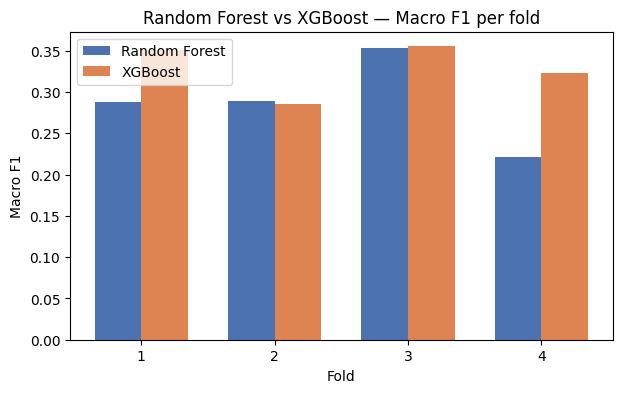

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
x = comparison['fold']
ax.bar(x - width/2, comparison['rf_macro_f1'], width, label='Random Forest', color='#4C72B0')
ax.bar(x + width/2, comparison['xgb_macro_f1'], width, label='XGBoost', color='#DD8452')
ax.set_xlabel("Fold")
ax.set_ylabel("Macro F1")
ax.set_title("Random Forest vs XGBoost — Macro F1 per fold")
ax.set_xticks(x)
ax.legend()
plt.show()

## Findings

XGBoost modestly outperforms Random Forest on average (mean Macro F1
+0.041), but the improvement is not uniform across folds — folds 2 and
3 are close to a tie, and the gap is concentrated almost entirely in
folds 1 and 4.

**Fold 4 is the clearest evidence of complexity helping.** Random
Forest collapsed there, predicting DOWN on nearly every day
(`recall_down ≈ 0.92`) while almost never catching UP or NEUTRAL days —
a degenerate, low-value prediction pattern despite a superficially high
recall on one class. XGBoost on the same fold still leans DOWN-heavy
(`recall_down ≈ 0.76`) but far less severely, and its Macro F1 nearly
doubles Random Forest's on that fold. This suggests complexity buys
robustness against a specific regime shift more than it buys raw
accuracy everywhere.

**Fold 2 is a shared failure mode, not a Random-Forest-specific one.**
Both models heavily over-predict UP that period (RF `recall_up≈0.79`,
XGBoost `recall_up≈0.83`) while almost never catching DOWN days. Fold
2's validation year (2021) was a strong post-COVID recovery year per
the project roadmap, so both models likely latched onto a persistent
uptrend rather than learning direction generally — added complexity
alone didn't fix this.

**NEUTRAL recall is weak in both models** (roughly 0.10–0.26 across all
folds), despite explicit class-imbalance handling in both. Since this
holds regardless of model choice, it points to the ±0.25% labeling
threshold itself rather than a model limitation — worth flagging to
Arindam, since it will affect Khushi's LSTM and the final comparison
table the same way.

**Bottom line for the research question:** increasing model complexity
(Random Forest → XGBoost) gives a real but modest improvement,
concentrated in resisting single-class collapse during at least one
regime shift, rather than a uniform accuracy gain. Whether LSTM extends
this trend further is the open question for Khushi's part.